In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scanpy.external as sce
from scipy.stats import spearmanr
import scvi
from scvi.external import SysVI
import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
from scib_metrics.benchmark import Benchmarker
from scib_metrics.benchmark import BioConservation, BatchCorrection
import psutil
import torch

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 2

# Load data

In [2]:
%%time
# h5ad built in Hematokytos/anndatas/integrate_scfib_ihsc.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/updated_adata/fib_ihsc_processed.h5ad"
fdata = sc.read_h5ad(fpath)

# clean up obs
cols_to_keep = ['batch', 'barcoded_phase', 'cluster']
fdata.obs = fdata.obs[cols_to_keep]

display(fdata)
fdata.obs.head()

AnnData object with n_obs × n_vars = 15317 × 23434
    obs: 'batch', 'barcoded_phase', 'cluster'
    var: 'gene_id', 'gene_type', 'Chromosome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'batch_colors', 'cluster_colors', 'draw_graph', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'phase_colors'
    obsm: 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_pca_original'
    varm: 'PCs'
    layers: 'log_norm', 'raw_counts'
    obsp: 'connectivities', 'distances'

CPU times: user 400 ms, sys: 2.56 s, total: 2.96 s
Wall time: 5.81 s


,batch,barcoded_phase,cluster
AAACCCAAGGTTACCT-1_hsc,hsc,unknown,R2
AAACCCAAGTTGAAGT-1_hsc,hsc,unknown,R2
AAACCCAAGTTGTCGT-1_hsc,hsc,unknown,C5
AAACCCACAGAAGCGT-1_hsc,hsc,unknown,C4
AAACCCACAGGAGGTT-1_hsc,hsc,unknown,R2


In [4]:
%%time

# h5ad built in Hematokytos/anndatas/timeseries_reprogram.ipynb
fpath = "/nfs/turbo/umms-indikar/shared/projects/parse/anndatas/parse_processed.h5ad"
# fpath = "/scratch/indikar_root/indikar1/shared_data/parse/anndata/parse_processed.h5ad"

pdata = sc.read_h5ad(fpath)
pdata.obs_names = pdata.obs['bc_wells'].astype(str) # rename obs index as cell id

# clean up obs
cols_to_keep = ['sample', 'condition_group_wTD', 'cluster_str']
pdata.obs = pdata.obs[cols_to_keep]

display(pdata)
pdata.obs.head()

AnnData object with n_obs × n_vars = 6172 × 18697
    obs: 'sample', 'condition_group_wTD', 'cluster_str'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_str_colors', 'draw_graph', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'phase_colors', 'sample_colors', 'umap'
    obsm: 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_pca_original', 'X_umap'
    varm: 'PCs'
    layers: 'log_norm', 'raw_counts'
    obsp: 'connectivities', 'distances'

CPU times: user 254 ms, sys: 627 ms, total: 881 ms
Wall time: 1.87 s


,sample,condition_group_wTD,cluster_str
bc_wells,,,
01_01_16,Control1_1,Control,C1
01_01_28,Control1_1,Control,C1
01_01_29,Control1_1,Control,C1
01_01_47,Control1_1,Control,C1
01_02_10,Control1_1,Control,C1


# Combine

In [4]:
adata = an.concat(
    [fdata, pdata],
    join="outer", # keep all genes from both datasets
)

# remove old representations for clarity
adata.obsm.clear()

adata

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str'
    layers: 'log_norm', 'raw_counts'

In [5]:
# add batch
adata.obs['batch'] = adata.obs['batch'].cat.add_categories(['parse'])
adata.obs['batch'] = adata.obs['batch'].fillna('parse')
adata.obs['batch'].value_counts()

batch
hsc      8357
fib      6960
parse    6174
Name: count, dtype: int64

# Basic preprocessing and filtering

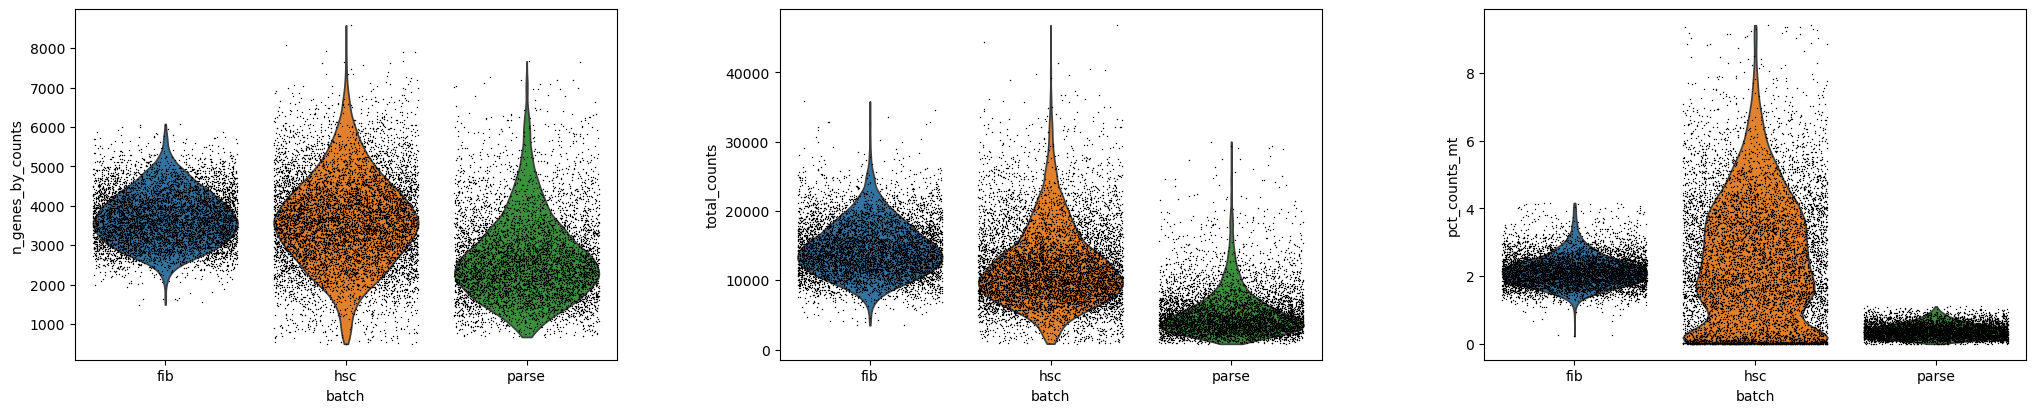

In [6]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], layer='raw_counts', inplace=True, log1p=True)

plt.rcdefaults()
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    groupby='batch',
)

In [7]:
adata.obs.groupby('batch', observed=True)['total_counts'].describe()

,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
fib,6960.0,14570.496408,3911.524830,3503.0,11768.0,14159.5,17002.25,35829.0
hsc,8357.0,12142.367596,5747.203152,856.0,8172.0,11091.0,14964.00,46815.0
parse,6174.0,5413.224652,3547.821337,830.0,3112.5,4508.0,6619.25,30005.0


In [8]:
# cells already filtered independently

adata.X = adata.layers['raw_counts']

# filter genes
sc.pp.filter_genes(adata, min_counts=10)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

normalizing counts per cell
    finished (0:00:01)


AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'batch_colors', 'log1p'
    layers: 'log_norm', 'raw_counts'

# Score cell cycle

In [9]:
%%time
regev_genes = [x.strip() for x in open('/home/jrcwycy/githubrepositories/Hybrid/resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
    layer='log_norm',
)

adata.obs[['phase']].head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:03)
computing score 'G2M_score'
    finished (0:00:03)
CPU times: user 3.64 s, sys: 3.1 s, total: 6.74 s
Wall time: 6.8 s


,phase
AAACCCAAGGTTACCT-1_hsc,G1
AAACCCAAGTTGAAGT-1_hsc,G1
AAACCCAAGTTGTCGT-1_hsc,S
AAACCCACAGAAGCGT-1_hsc,G1
AAACCCACAGGAGGTT-1_hsc,G1


In [10]:
# make sure there are no missing values
adata.obs[["S_score", "G2M_score", "log1p_total_counts"]].isna().sum()

S_score               0
G2M_score             0
log1p_total_counts    0
dtype: int64

# Filter pass genes

In [11]:
%%time 
# === Load and filter GTF ===
gpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/RefGenome/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)

gtf = gtf[gtf['Feature'] == 'gene']

protein_coding = gtf[gtf['gene_type'] == 'protein_coding']['gene_name'].unique().tolist()
print(f"N protein coding genes: {len(protein_coding)}")

print(gtf.shape)
gtf.head()

N protein coding genes: 19405
(38606, 27)
CPU times: user 11.5 s, sys: 2.48 s, total: 13.9 s
Wall time: 14.1 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
0,GL000009.2,ENSEMBL,gene,56139,58376,.,-,.,ENSG00000278704,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,GL000194.1,ENSEMBL,gene,53589,115018,.,-,.,ENSG00000277400,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,GL000194.1,ENSEMBL,gene,53593,115055,.,-,.,ENSG00000274847,1,...,NaN,NaN,NaN,NaN,NaN,NaN,HGNC:31102,NaN,NaN,NaN
34,GL000195.1,ENSEMBL,gene,42938,49164,.,-,.,ENSG00000276256,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,GL000213.1,ENSEMBL,gene,108006,139659,.,-,.,ENSG00000277630,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "/home/jrcwycy/githubrepositories/Hybrid/resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "/home/jrcwycy/githubrepositories/Hybrid/resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow KEGG cell cycle genes
fpath = "/home/jrcwycy/githubrepositories/Hybrid/resources/KEGG_HUMAN_CELL_CYCLE.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())

adata

filter_pass
True     14832
False     9351


AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass'
    uns: 'batch_colors', 'log1p'
    layers: 'log_norm', 'raw_counts'

# HVGs

extracting highly variable genes
N HVGs: 3000
computing PCA
    with n_comps=50
    finished (0:00:29)


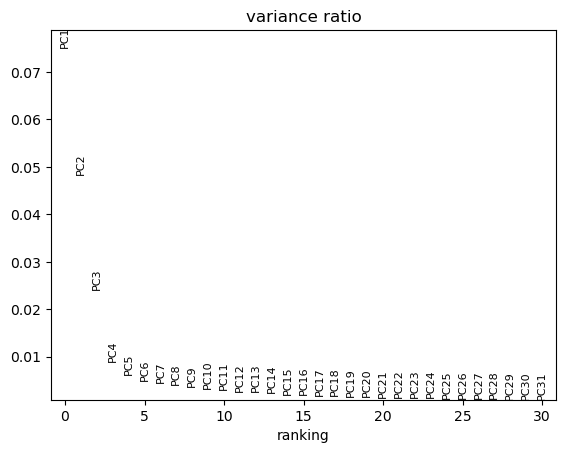

... storing 'phase' as categorical


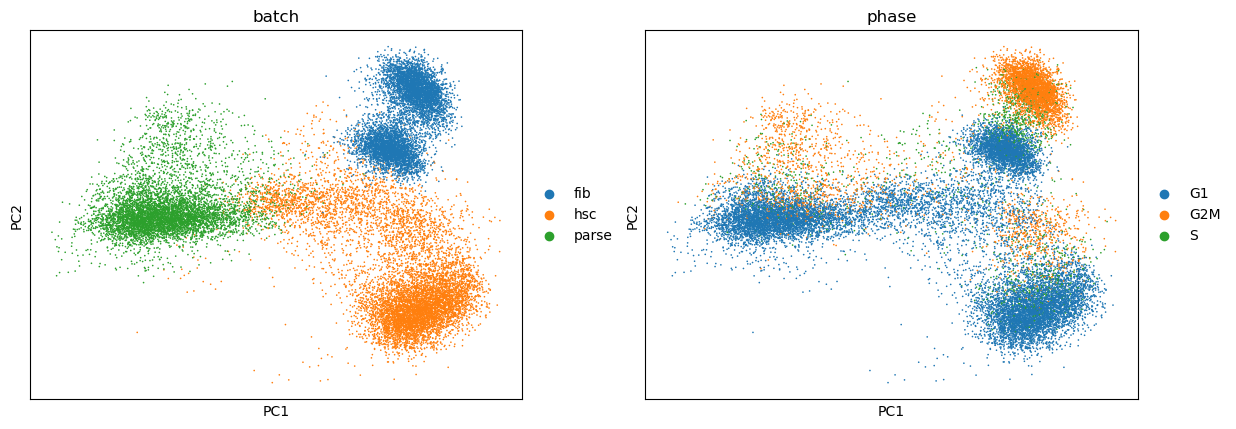

AnnData object with n_obs × n_vars = 21491 × 3000
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'batch_colors', 'log1p', 'hvg', 'pca', 'phase_colors'
    obsm: 'X_pca_unintegrated', 'X_pca'
    varm: 'PCs'
  

In [16]:
# subset for Filter pass genes
adata_int = adata.copy()

adata_int = adata_int[:, adata_int.var['filter_pass']].copy()
adata_int.X = adata_int.layers['raw_counts'].copy()

# HVGs
sc.pp.highly_variable_genes(
    adata_int,
    flavor='seurat_v3',
    batch_key='batch',
    n_top_genes=3000,
    
)

print(f'N HVGs: {len(adata_int.var[adata_int.var['highly_variable']])}')


adata_int = adata_int[:, adata_int.var['highly_variable']].copy()

# PCA
adata_int.X = adata_int.layers['log_norm'].copy()

sc.pp.scale(adata_int, max_value=10)
sc.pp.pca(adata_int)

sc.pl.pca_variance_ratio(adata_int)

sc.pl.pca(adata_int, color=['batch', 'phase'])
adata_int

In [17]:
# save in original adata for benchmarking later on
adata.obsm["X_pca_unintegrated"] = adata_int.obsm["X_pca"].copy()
adata

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass'
    uns: 'batch_colors', 'log1p'
    obsm: 'X_pca_unintegrated'
    layers: 'log_norm', 'raw_counts'

# Harmony

## batch only

In [18]:
adata_harmony = adata_int.copy()

sce.pp.harmony_integrate(
    adata_harmony,
    key='batch',
)

# save to original adata
adata.obsm["X_harmony_batch_only"] = adata_harmony.obsm["X_pca_harmony"].copy()

2026-06-10 12:20:00,936 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-10 12:20:00 | [INFO] Computing initial centroids with sklearn.KMeans...
2026-06-10 12:20:05,963 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-06-10 12:20:05 | [INFO] sklearn.KMeans initialization complete.
2026-06-10 12:20:06,082 - harmonypy - INFO - Iteration 1 of 10
2026-06-10 12:20:06 | [INFO] Iteration 1 of 10
2026-06-10 12:20:11,873 - harmonypy - INFO - Iteration 2 of 10
2026-06-10 12:20:11 | [INFO] Iteration 2 of 10
2026-06-10 12:20:17,536 - harmonypy - INFO - Converged after 2 iterations
2026-06-10 12:20:17 | [INFO] Converged after 2 iterations


## regress cell cycle

In [19]:
adata_harmony = adata_int.copy()

adata_harmony.X = adata_harmony.layers['log_norm']

sc.pp.regress_out(
    adata_harmony,
    keys=["S_score", "G2M_score"]
)

sc.pp.scale(adata_harmony, max_value=10)
sc.tl.pca(adata_harmony)

sce.pp.harmony_integrate(
    adata_harmony,
    key='batch',
)

# save to original adata
adata.obsm["X_harmony_regress_cc"] = adata_harmony.obsm["X_pca_harmony"].copy()
adata

regressing out ['S_score', 'G2M_score']
    sparse input is densified and may lead to high memory use


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


    finished (0:00:03)
computing PCA
    with n_comps=50
    finished (0:00:30)


2026-06-10 12:25:23,949 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-10 12:25:23 | [INFO] Computing initial centroids with sklearn.KMeans...
2026-06-10 12:25:28,689 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-06-10 12:25:28 | [INFO] sklearn.KMeans initialization complete.
2026-06-10 12:25:28,808 - harmonypy - INFO - Iteration 1 of 10
2026-06-10 12:25:28 | [INFO] Iteration 1 of 10
2026-06-10 12:25:34,470 - harmonypy - INFO - Iteration 2 of 10
2026-06-10 12:25:34 | [INFO] Iteration 2 of 10
2026-06-10 12:25:40,184 - harmonypy - INFO - Converged after 2 iterations
2026-06-10 12:25:40 | [INFO] Converged after 2 iterations


AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass'
    uns: 'batch_colors', 'log1p'
    obsm: 'X_pca_unintegrated', 'X_harmony_batch_only', 'X_harmony_regress_cc'
    layers: 'log_norm', 'raw_counts'

# scVI

## batch only

(21491, 3000)


INFO: GPU available: True (cuda), used: True
2026-06-10 12:29:57 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-06-10 12:29:57 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-06-10 12:29:57 | [INFO] HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-06-10 12:29:57 | [INFO] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 20 records. Best score: 1748.442. Signaling Trainer to stop.


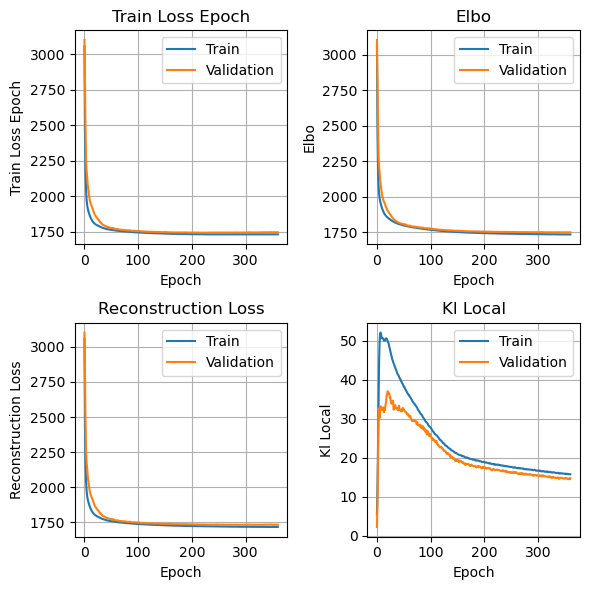

CPU times: user 4min 59s, sys: 9.77 s, total: 5min 9s
Wall time: 5min 13s


In [21]:
%%time
batch_key = "batch"

adata_scvi = adata_int.copy()
print(adata_scvi.shape)

scvi.model.SCVI.setup_anndata(
    adata_scvi, 
    layer='raw_counts',
    batch_key=batch_key,
)

model_batch_only = scvi.model.SCVI(
    adata_scvi,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dropout_rate=0.25,
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model_batch_only.train(
    max_epochs=1000,
    accelerator='gpu',
    early_stopping_patience=20,
    early_stopping=True,
    batch_size=2048,
    train_size=0.8,
)

history = model_batch_only.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 100
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [22]:
### add embedding to adata
adata.obsm['X_scvi_batch_only'] = model_batch_only.get_latent_representation()
adata

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass'
    uns: 'batch_colors', 'log1p'
    obsm: 'X_pca_unintegrated', 'X_harmony_batch_only', 'X_harmony_regress_cc', 'X_scvi_batch_only'
    layers: 'log_norm', 'raw_counts'

### scANVI

In [23]:
### Group labels
conditions = [
    adata_scvi.obs['batch'] == 'fib', # fib controls
    adata_scvi.obs['batch'] == 'parse', # parse cells
    (adata_scvi.obs['batch'] == 'hsc') & (adata_scvi.obs['cluster'].isin(['R1', 'R2', 'R3'])), # D48 CD34+ cells
    (adata_scvi.obs['batch'] == 'hsc') & (adata_scvi.obs['cluster'].isin(['C4', 'C5'])) # spike-in controls
]

choices = [
    'Control',
    adata_scvi.obs['condition_group_wTD'].astype(str), 
    adata_scvi.obs['cluster'].astype(str),#'D48',
    'spike-in'
]

adata_scvi.obs['group_label'] = np.select(conditions, choices, default=np.nan)

# convert back to categorical
adata_scvi.obs['group_label'] = pd.Categorical(adata_scvi.obs['group_label'])
adata_scvi.obs['group_label'].value_counts()

group_label
Control     7842
R2          4343
R1          1982
D14         1973
D7          1529
spike-in    1508
D21         1331
R3           524
D0           459
Name: count, dtype: int64

In [24]:
adata_scvi.obs["scanvi_label"] = "Unknown"

fib_control_mask = (
    (adata_scvi.obs["batch"] == "fib") # 6960
    |
    ((adata_scvi.obs["batch"] == "parse") & (adata_scvi.obs["group_label"] == "Control")) # 882
    # |
    # ((bdata.obs["batch"] == "hsc") & (bdata.obs["group_label"] == 'spike-in')) # 1508
)

adata_scvi.obs.loc[fib_control_mask, "scanvi_label"] = "Fibroblast_control"

display(adata_scvi.obs['scanvi_label'].value_counts())

# Define D48 CD34+ cells
d48_mask = adata_scvi.obs['cluster'].isin(['R2', 'R3'])
   
adata_scvi.obs.loc[d48_mask, "scanvi_label"] = "D48_CD34pos_HSC_like"

adata_scvi.obs['scanvi_label'].value_counts()

scanvi_label
Unknown               13649
Fibroblast_control     7842
Name: count, dtype: int64

scanvi_label
Unknown                 8782
Fibroblast_control      7842
D48_CD34pos_HSC_like    4867
Name: count, dtype: int64

In [25]:
%%time
scanvi_model_batch_only = scvi.model.SCANVI.from_scvi_model(
    model_batch_only,
    adata=adata_scvi,
    labels_key="scanvi_label",
    unlabeled_category="Unknown",
)

scanvi_model_batch_only.train(
    max_epochs=50, 
    accelerator="gpu",
    devices="auto",
    early_stopping=True,
    early_stopping_patience=10,
    plan_kwargs={'lr': 1e-4},
)

INFO     Training for 50 epochs.                                                                                   


INFO: GPU available: True (cuda), used: True
2026-06-10 12:40:27 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-06-10 12:40:27 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-06-10 12:40:27 | [INFO] HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-06-10 12:40:27 | [INFO] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 1722.353. Signaling Trainer to stop.
CPU times: user 47.8 s, sys: 522 ms, total: 48.3 s
Wall time: 49.2 s


In [26]:
### add embedding to adata
adata.obsm['X_scANVI_batch_only'] = scanvi_model_batch_only.get_latent_representation()
adata

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass'
    uns: 'batch_colors', 'log1p'
    obsm: 'X_pca_unintegrated', 'X_harmony_batch_only', 'X_harmony_regress_cc', 'X_scvi_batch_only', 'X_scANVI_batch_only'
    layers: 'log_norm', 'raw_counts'

In [183]:
# add predictions to adata
adata_scvi.obs['scanvi_prediction_batch_only'] = scanvi_model_batch_only.predict(adata_scvi)
adata.obs['scanvi_prediction_batch_only'] = adata_scvi.obs['scanvi_prediction_batch_only'].copy()

# get probabilities
probs = scanvi_model_batch_only.predict(adata_scvi, soft=True)
adata.obs["prob_D48_like_batch_only"] = probs["D48_CD34pos_HSC_like"].values
adata.obs["prob_fibroblast_control_batch_only"] = probs["Fibroblast_control"].values
adata

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass'
    uns: 'batch_colors', 'log1p'
    obsm: 'X_pca_unintegrated', 'X

## cell cycle covars

INFO: GPU available: True (cuda), used: True
2026-06-10 12:42:28 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-06-10 12:42:28 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs


(21491, 3000)


2026-06-10 12:42:28 | [INFO] HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-06-10 12:42:28 | [INFO] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 20 records. Best score: 1733.526. Signaling Trainer to stop.


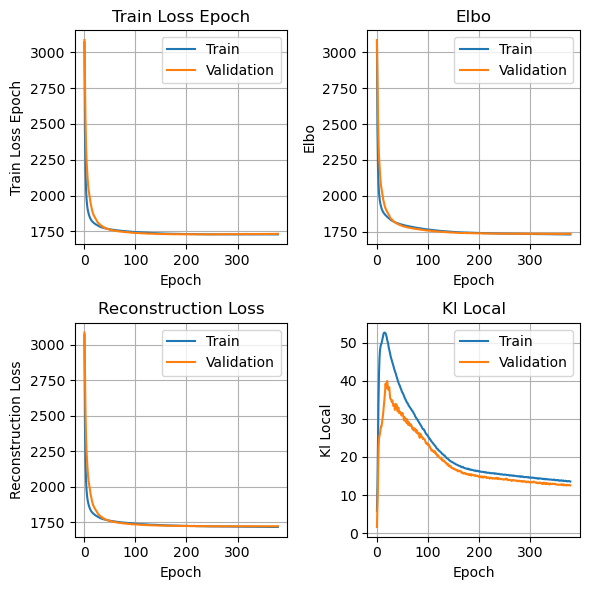

CPU times: user 5min 24s, sys: 25.1 s, total: 5min 49s
Wall time: 5min 57s


In [27]:
%%time
batch_key = "batch"

adata_scvi_cc = adata_int.copy()
print(adata_scvi_cc.shape)

scvi.model.SCVI.setup_anndata(
    adata_scvi_cc, 
    layer='raw_counts',
    batch_key=batch_key,
    continuous_covariate_keys=[
        'S_score', 
        'G2M_score',
    ],
)

model = scvi.model.SCVI(
    adata_scvi_cc,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dropout_rate=0.25,
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=1000,
    accelerator='gpu',
    early_stopping_patience=20,
    early_stopping=True,
    batch_size=2048,
    train_size=0.8,
)

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 100
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [28]:
### add embedding to adata
adata.obsm['X_scvi_cc_covar'] = model.get_latent_representation()
adata

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass'
    uns: 'batch_colors', 'log1p'
    obsm: 'X_pca_unintegrated', 'X_harmony_batch_only', 'X_harmony_regress_cc', 'X_scvi_batch_only', 'X_scANVI_batch_only', 'X_scvi_cc_covar'
    layers: 'log_norm', 'raw_counts'

### scANVI

In [29]:
### Group labels
conditions = [
    adata_scvi_cc.obs['batch'] == 'fib', # fib controls
    adata_scvi_cc.obs['batch'] == 'parse', # parse cells
    (adata_scvi_cc.obs['batch'] == 'hsc') & (adata_scvi_cc.obs['cluster'].isin(['R1', 'R2', 'R3'])), # D48 CD34+ cells
    (adata_scvi_cc.obs['batch'] == 'hsc') & (adata_scvi_cc.obs['cluster'].isin(['C4', 'C5'])) # spike-in controls
]

choices = [
    'Control',
    adata_scvi_cc.obs['condition_group_wTD'].astype(str), 
    adata_scvi_cc.obs['cluster'].astype(str),#'D48',
    'spike-in'
]

adata_scvi_cc.obs['group_label'] = np.select(conditions, choices, default=np.nan)

# convert back to categorical
adata_scvi_cc.obs['group_label'] = pd.Categorical(adata_scvi_cc.obs['group_label'])
adata_scvi_cc.obs['group_label'].value_counts()

group_label
Control     7842
R2          4343
R1          1982
D14         1973
D7          1529
spike-in    1508
D21         1331
R3           524
D0           459
Name: count, dtype: int64

In [30]:
adata_scvi_cc.obs["scanvi_label"] = "Unknown"

fib_control_mask = (
    (adata_scvi_cc.obs["batch"] == "fib") # 6960
    |
    ((adata_scvi_cc.obs["batch"] == "parse") & (adata_scvi_cc.obs["group_label"] == "Control")) # 882
    # |
    # ((bdata.obs["batch"] == "hsc") & (bdata.obs["group_label"] == 'spike-in')) # 1508
)

adata_scvi_cc.obs.loc[fib_control_mask, "scanvi_label"] = "Fibroblast_control"

display(adata_scvi_cc.obs['scanvi_label'].value_counts())

# Define D48 CD34+ cells
d48_mask = adata_scvi_cc.obs['cluster'].isin(['R2', 'R3'])
   
adata_scvi_cc.obs.loc[d48_mask, "scanvi_label"] = "D48_CD34pos_HSC_like"

adata_scvi_cc.obs['scanvi_label'].value_counts()

scanvi_label
Unknown               13649
Fibroblast_control     7842
Name: count, dtype: int64

scanvi_label
Unknown                 8782
Fibroblast_control      7842
D48_CD34pos_HSC_like    4867
Name: count, dtype: int64

In [31]:
%%time
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    model,
    adata=adata_scvi_cc,
    labels_key="scanvi_label",
    unlabeled_category="Unknown",
)

scanvi_model.train(
    max_epochs=50, 
    accelerator="gpu",
    devices="auto",
    early_stopping=True,
    early_stopping_patience=10,
    plan_kwargs={'lr': 1e-4},
)

INFO     Training for 50 epochs.                                                                                   


INFO: GPU available: True (cuda), used: True
2026-06-10 12:49:15 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-06-10 12:49:15 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-06-10 12:49:15 | [INFO] HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-06-10 12:49:15 | [INFO] LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 1733.243. Signaling Trainer to stop.
CPU times: user 54.6 s, sys: 501 ms, total: 55.1 s
Wall time: 56.1 s


In [32]:
### add embedding to adata
adata.obsm['X_scANVI_cc_covar'] = scanvi_model.get_latent_representation()
adata

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass'
    uns: 'batch_colors', 'log1p'
    obsm: 'X_pca_unintegrated', 'X_harmony_batch_only', 'X_harmony_regress_cc', 'X_scvi_batch_only', 'X_scANVI_batch_only', 'X_scvi_cc_covar', 'X_scANVI_cc_covar'
    layers: 'log_norm', 'raw_counts'

In [185]:
# add predictions to adata
adata_scvi_cc.obs['scanvi_prediction_cc_covar'] = scanvi_model.predict(adata_scvi_cc)
adata.obs['scanvi_prediction_cc_covar'] = adata_scvi_cc.obs['scanvi_prediction_cc_covar'].copy()

# get probabilities
probs = scanvi_model.predict(adata_scvi_cc, soft=True)
adata.obs["prob_D48_like_cc_covar"] = probs["D48_CD34pos_HSC_like"].values
adata.obs["prob_fibroblast_control_cc_covar"] = probs["Fibroblast_control"].values
adata

AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', '

# Labels

In [33]:
### add cell type labels to original adata

### Group labels
conditions = [
    adata.obs['batch'] == 'fib', # fib controls
    adata.obs['batch'] == 'parse', # parse cells
    (adata.obs['batch'] == 'hsc') & (adata.obs['cluster'].isin(['R1', 'R2', 'R3'])), # D48 CD34+ cells
    (adata.obs['batch'] == 'hsc') & (adata.obs['cluster'].isin(['C4', 'C5'])) # spike-in controls
]

choices = [
    'Control',
    adata.obs['condition_group_wTD'].astype(str), 
    adata.obs['cluster'].astype(str),#'D48',
    'spike-in'
]

adata.obs['group_label'] = np.select(conditions, choices, default=np.nan)

# convert back to categorical
adata.obs['group_label'] = pd.Categorical(adata.obs['group_label'])
adata.obs['group_label'].value_counts()

group_label
Control     7842
R2          4343
R1          1982
D14         1973
D7          1529
spike-in    1508
D21         1331
R3           524
D0           459
Name: count, dtype: int64

In [34]:
adata.obs["scanvi_label"] = "Unknown"

fib_control_mask = (
    (adata.obs["batch"] == "fib") # 6960
    |
    ((adata.obs["batch"] == "parse") & (adata.obs["group_label"] == "Control")) # 882
    # |
    # ((bdata.obs["batch"] == "hsc") & (bdata.obs["group_label"] == 'spike-in')) # 1508
)

adata.obs.loc[fib_control_mask, "scanvi_label"] = "Fibroblast_control"

display(adata.obs['scanvi_label'].value_counts())

# Define D48 CD34+ cells
d48_mask = adata.obs['cluster'].isin(['R2', 'R3'])
   
adata.obs.loc[d48_mask, "scanvi_label"] = "D48_CD34pos_HSC_like"

adata.obs['scanvi_label'].value_counts()

scanvi_label
Unknown               13649
Fibroblast_control     7842
Name: count, dtype: int64

scanvi_label
Unknown                 8782
Fibroblast_control      7842
D48_CD34pos_HSC_like    4867
Name: count, dtype: int64

In [37]:
### assign cell type labels for evaluation
# useful if biological state labels (but not useful if it just corresponds to batch, e.g. different library prep, etc.)

adata.obs["eval_label"] = adata.obs["scanvi_label"].astype(str)

mask = adata.obs["scanvi_label"].astype(str) == "Unknown"

# get D0, D7, D14, D21 
adata.obs.loc[mask, "eval_label"] = (
    "unknown_" + adata.obs.loc[mask, "group_label"].astype(str)
)

adata.obs["eval_label"] = adata.obs["eval_label"].astype("category")

adata.obs["eval_label"].value_counts()

eval_label
Fibroblast_control      7842
D48_CD34pos_HSC_like    4867
unknown_R1              1982
unknown_D14             1973
unknown_D7              1529
unknown_spike-in        1508
unknown_D21             1331
unknown_D0               459
Name: count, dtype: int64

In [39]:
pd.crosstab(
    adata.obs['eval_label'],
    adata.obs['batch']
)

batch,fib,hsc,parse
eval_label,,,
D48_CD34pos_HSC_like,0,4867,0
Fibroblast_control,6960,0,882
unknown_D0,0,0,459
unknown_D14,0,0,1973
unknown_D21,0,0,1331
unknown_D7,0,0,1529
unknown_R1,0,1982,0
unknown_spike-in,0,1508,0


In [ ]:
# ^These labels are strongly confounded with batch (i.e. most labels exist in only 1 batch)

# Running scIB on these labels over the full dataset is problematic because:
# * Batch correction metrics will ask methods to mix fib, hsc, and parse
# * Biological conservation metrics will ask methods to preserve labels that are almost batch-spceific
# * These two goals are conflicting!

# Benchmark is being asked to remove and preserve the same axis of variation

# Run separate evaluations:
# * batch correction test between fib + parse
# * within-parse biological preservation
# * within-hsc biological preservation

In [44]:
adata.obs["non_reprogrammed"] = False

fib_control_mask = (
    (adata.obs["batch"] == "fib") # 6960
    |
    ((adata.obs["batch"] == "parse") & (adata.obs["group_label"].isin(["Control", "D0"]))) # 882 + 459
    |
    ((adata.obs["batch"] == "hsc") & (adata.obs["group_label"] == 'spike-in')) # 1508
)

adata.obs.loc[fib_control_mask, "non_reprogrammed"] = True

display(adata.obs['non_reprogrammed'].value_counts())
    
# # Define D48 CD34+ cells
# d48_mask = adata.obs['cluster'].isin(['R2', 'R3'])
   
# adata.obs.loc[d48_mask, "eval_label_2"] = "D48_CD34pos_HSC_like"

# adata.obs['eval_label_2'].value_counts()

non_reprogrammed
False    11682
True      9809
Name: count, dtype: int64

In [46]:
pd.crosstab(
    adata.obs['non_reprogrammed'],
    adata.obs['batch']
)

batch,fib,hsc,parse
non_reprogrammed,,,
False,0,6849,4833
True,6960,1508,1341


# Write out

In [187]:
# # save adata
adata.write("/scratch/indikar_root/indikar1/shared_data/parse/anndata/scfib_hsc_parse_integration.h5ad")
adata

... storing 'scanvi_prediction_batch_only' as categorical
... storing 'scanvi_prediction_cc_covar' as categorical


AnnData object with n_obs × n_vars = 21491 × 24183
    obs: 'batch', 'barcoded_phase', 'cluster', 'condition', 'condition_group_wTD', 'cluster_str', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'group_label', 'scanvi_label', 'eval_label', 'eval_label_2', 'non_reprogrammed', 'scanvi_prediction_batch_only', 'prob_D48_like_batch_only', 'prob_fibroblast_control_batch_only', 'scanvi_prediction_cc_covar', 'prob_D48_like_cc_covar', 'prob_fibroblast_control_cc_covar'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', '